In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import cv2
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from zipfile import ZipFile
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications import ConvNeXtTiny, EfficientNetV2B0
from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as effv2_preprocess


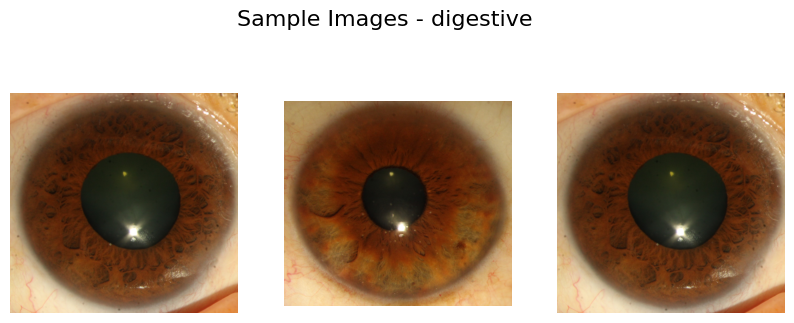

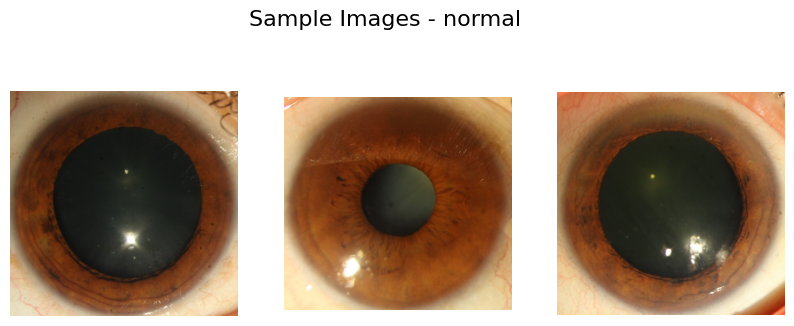

In [5]:
path = '/content/drive/MyDrive/Research/New folder'
classes = ['digestive', 'normal']

# ==========================================
# 3. VISUALIZE SAMPLE IMAGES
# ==========================================
for cat in classes:
    image_dir = f'{path}/{cat}'
    images = os.listdir(image_dir)

    fig, ax = plt.subplots(1, 3, figsize=(10, 4))
    fig.suptitle(f'Sample Images - {cat}', fontsize=16)

    for i in range(3):
        img = np.array(Image.open(os.path.join(image_dir, images[np.random.randint(len(images))])))
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()


In [6]:
# ==========================================
# 4. PARAMETERS
# ==========================================
IMG_SIZE = 256
BATCH_SIZE = 64
EPOCHS_PHASE1 = 20
EPOCHS_PHASE2 = 20
SPLIT = 0.2

# ==========================================
# 5. LOAD & PREPROCESS DATA
# ==========================================
X, Y = [], []

for i, cat in enumerate(classes):
    images = glob(f'{path}/{cat}/*.JPG')

    for image in images:
        img = cv2.imread(image)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # IMPORTANT
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        Y.append(i)

X = np.array(X, dtype="float32")
Y = np.array(Y)

Y_cat = keras.utils.to_categorical(Y, num_classes=len(classes))

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y_cat, test_size=SPLIT, random_state=42, stratify=Y
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

Train: (124, 256, 256, 3), Validation: (32, 256, 256, 3)


In [7]:
# ==========================================
# 6. CLASS WEIGHTS (OPTIONAL BUT RECOMMENDED)
# ==========================================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y),
    y=Y
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [8]:
# ==========================================
# 7. DATA AUGMENTATION
# ==========================================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
], name="augmentation")


In [9]:
# ==========================================
# 8. HYBRID MODEL ARCHITECTURE
# ==========================================
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(input_layer)

# Preprocessing per branch
convnext_input = convnext_preprocess(x)
effnet_input = effv2_preprocess(x)

# ===============================
# Branch 1: ConvNeXtTiny
# ===============================
base_convnext = ConvNeXtTiny(
    include_top=False,
    weights="imagenet",
    input_tensor=convnext_input
)
base_convnext.trainable = False

convnext_feat = layers.GlobalAveragePooling2D()(base_convnext.output)

# ===============================
# Branch 2: EfficientNetV2B0
# ===============================
base_effnet = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_tensor=effnet_input
)
base_effnet.trainable = False

effnet_feat = layers.GlobalAveragePooling2D()(base_effnet.output)

# ===============================
# Feature Fusion
# ===============================
combined = layers.Concatenate()([convnext_feat, effnet_feat])

# ===============================
# Classification Head
# ===============================
x = layers.Dense(512, activation="relu")(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.6)(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

output = layers.Dense(len(classes), activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output)
model.summary()


111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ augmentation[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 128, 128,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 128, 128,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 64, 64,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 64, 64,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 64, 64,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 64, 64,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 64, 64,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 64, 64,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 64, 64,    │        512 │ block2b_expand_c

 Total params: 34,923,442 (133.22 MB)

 Trainable params: 1,182,466 (4.51 MB)

 Non-trainable params: 33,740,976 (128.71 MB)

In [10]:
# ==========================================
# 9. COMPILE (PHASE 1)
# ==========================================
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)


In [11]:
# ==========================================
# 10. TRAINING – PHASE 1 (FEATURE EXTRACTION)
# ==========================================
history_1 = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS_PHASE1,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 44s 14s/step - accuracy: 0.4839 - loss: 1.3275 - val_accuracy: 0.4375 - val_loss: 0.7411
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.4790 - loss: 1.2290 - val_accuracy: 0.5000 - val_loss: 0.7256
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5059 - loss: 0.9942 - val_accuracy: 0.5312 - val_loss: 0.7082
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5640 - loss: 0.9473 - val_accuracy: 0.5938 - val_loss: 0.6908
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6221 - loss: 0.9704 - val_accuracy: 0.6250 - val_loss: 0.6757
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6438 - loss: 0.9603 - val_accuracy: 0.6250 - val_loss: 0.6611
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6171 - loss: 0.9643 - val_accuracy: 0.6562 - val_loss: 0.6505
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6593 - loss: 0.9986 - val_accuracy: 0.6562 - val_loss: 0.6397
Epoch 9/20
2/2

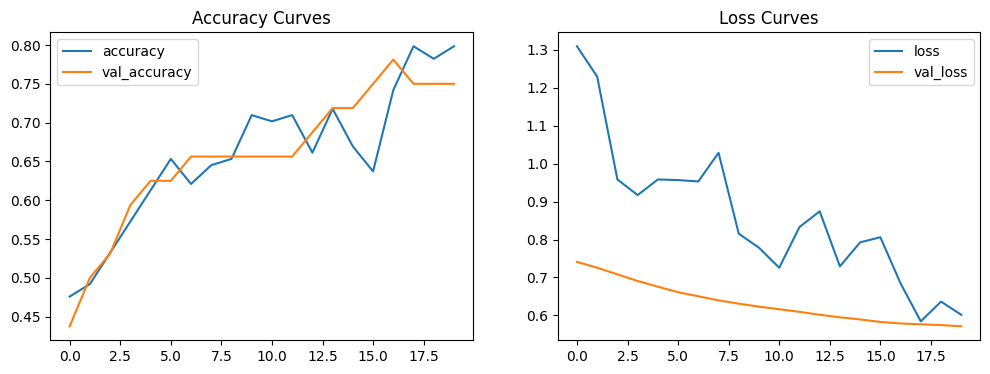

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


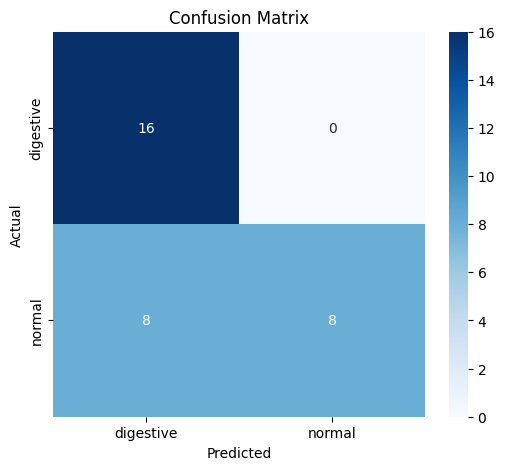

In [12]:
# Plot Accuracy and Loss
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
history_df = pd.DataFrame(history_1.history)

history_df[['accuracy', 'val_accuracy']].plot(ax=ax[0])
ax[0].set_title('Accuracy Curves')

history_df[['loss', 'val_loss']].plot(ax=ax[1])
ax[1].set_title('Loss Curves')
plt.show()

# Confusion Matrix
Y_pred = model.predict(X_val)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

cm = confusion_matrix(Y_true, Y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [13]:
# ==========================================
# 11. FINE-TUNING (PHASE 2)
# ==========================================
for layer in base_convnext.layers[-20:]:
    layer.trainable = True

for layer in base_effnet.layers[-20:]:
    layer.trainable = True


model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

history_2 = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS_PHASE2,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 41s 12s/step - accuracy: 0.7497 - loss: 0.6583 - val_accuracy: 0.7812 - val_loss: 0.5658
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.7295 - loss: 0.6677 - val_accuracy: 0.8125 - val_loss: 0.5683
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.6599 - loss: 0.8029 - val_accuracy: 0.8125 - val_loss: 0.5715
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.7078 - loss: 0.7397 - val_accuracy: 0.8125 - val_loss: 0.5725
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.7019 - loss: 0.8687 - val_accuracy: 0.8125 - val_loss: 0.5725
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.7288 - loss: 0.7218 - val_accuracy: 0.8125 - val_loss: 0.5748
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.7661 - loss: 0.6751 - val_accuracy: 0.8125 - val_loss: 0.5753
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.6757 - loss: 0.7705 - val_accuracy: 0.8125 - val_loss: 0.5773
Epoch 9/20
2/2

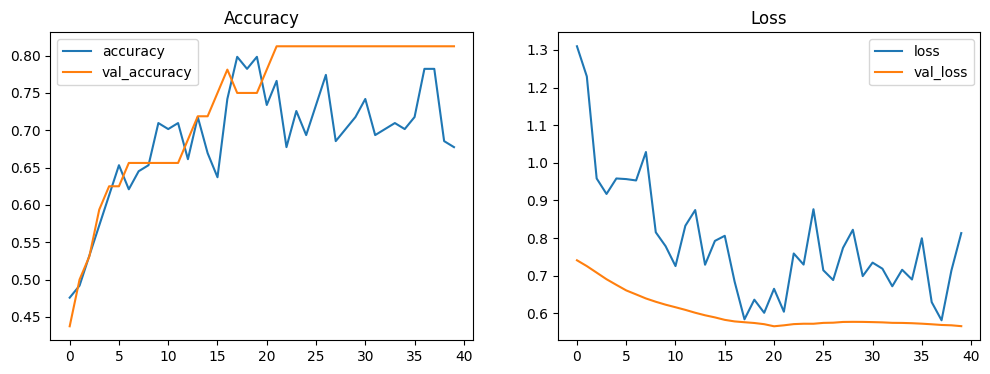

In [14]:
# ==========================================
# 12. TRAINING CURVES
# ==========================================
history = pd.concat([
    pd.DataFrame(history_1.history),
    pd.DataFrame(history_2.history)
], ignore_index=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
history[['accuracy', 'val_accuracy']].plot(ax=ax[0])
ax[0].set_title("Accuracy")

history[['loss', 'val_loss']].plot(ax=ax[1])
ax[1].set_title("Loss")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
              precision    recall  f1-score   support

   digestive       0.73      1.00      0.84        16
      normal       1.00      0.62      0.77        16

    accuracy                           0.81        32
   macro avg       0.86      0.81      0.81        32
weighted avg       0.86      0.81      0.81        32



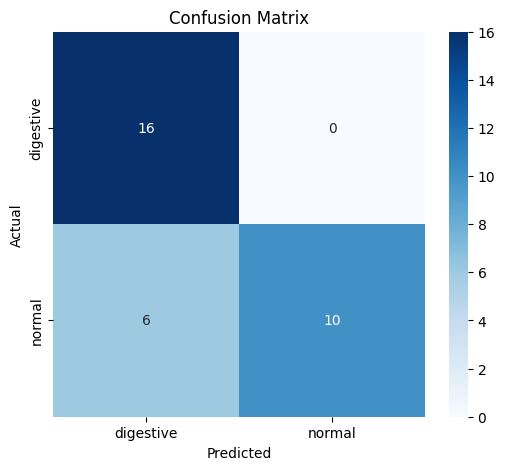

In [15]:
# ==========================================
# 13. EVALUATION
# ==========================================
Y_pred = model.predict(X_val)
Y_pred_cls = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

print(classification_report(Y_true, Y_pred_cls, target_names=classes))

cm = confusion_matrix(Y_true, Y_pred_cls)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()